# Laboratorio de IA Ética: Sesgos y Explicabilidad

**Bootcamp Python – PY4**  
**Módulo:** Machine Learning Avanzado y Feature Engineering  
Evaluación de IA Ética  

---

Para este análisis vamos a cambiar de dataset. Vamos a trabajar con **Adult Census Income**, un dataset del censo de Estados Unidos de 1994, donde el objetivo es predecir si una persona gana más o menos de 50,000 dólares al año. Elegimos este dataset porque contiene variables sensibles muy bien documentadas (`sex`, `race`, `native.country`), lo que nos permite investigar sesgos de forma mucho más concreta que con el dataset de crédito.

El plan de hoy:

1. Entrenar un modelo (mismo flujo que ya conocemos) sobre este nuevo dataset.
2. Usar SHAP para revisar si el modelo se apoya en variables sensibles.
3. Medir, con un chequeo simple, si el modelo reproduce o amplifica desigualdades ya presentes en los datos.
4. Escribir una reflexión crítica: ¿el modelo está tomando decisiones basadas en características irrelevantes o discriminatorias?

## 1. Preparar el entorno

Reutilizamos las mismas librerías de las sesiones anteriores.

In [1]:
!pip install xgboost shap lime scikit-learn joblib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

import xgboost as xgb
import shap
from lime.lime_tabular import LimeTabularExplainer

import matplotlib.pyplot as plt
import joblib

## 2. Cargar el dataset: Adult Census Income

Este dataset contiene información de más de 32,000 personas del censo de Estados Unidos de 1994. El objetivo es predecir si una persona gana más de 50,000 dólares al año (`income`).

Lo cargamos directamente desde GitHub, igual que hicimos con el dataset de crédito en la Sesión 1.

In [3]:
url = "https://raw.githubusercontent.com/pooja2512/Adult-Census-Income/master/adult.csv"
df = pd.read_csv(url)

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 3. Diccionario de variables

| Columna | Descripción |
|---|---|
| `age` | Edad de la persona |
| `workclass` | Tipo de empleador (privado, gobierno, independiente, etc.) |
| `fnlwgt` | Peso estadístico usado por el censo (no aporta información personal, se puede ignorar en el análisis) |
| `education` | Nivel educativo alcanzado |
| `education.num` | Años de educación, en formato numérico |
| `marital.status` | Estado civil |
| `occupation` | Ocupación |
| `relationship` | Rol dentro del núcleo familiar |
| `race` | Raza de la persona **(variable sensible)** |
| `sex` | Sexo de la persona **(variable sensible)** |
| `capital.gain` | Ganancias de capital |
| `capital.loss` | Pérdidas de capital |
| `hours.per.week` | Horas trabajadas por semana |
| `native.country` | País de nacimiento **(variable sensible)** |
| `income` | Variable objetivo: `>50K` o `<=50K` |

A diferencia de las sesiones anteriores, hoy no vamos a tratar `race`, `sex` y `native.country` como una nota al margen: van a ser el centro del análisis de esta sesión.

## 4. Exploración y manejo de valores faltantes

Antes de seguir, revisamos la distribución de la variable objetivo y buscamos valores faltantes. En este dataset, los valores faltantes no aparecen como `NaN`, sino como el símbolo `"?"`, así que primero los convertimos a `NaN` para poder tratarlos con las herramientas habituales de pandas.

Para mantener el ejercicio simple, vamos a eliminar las filas con datos faltantes (son una fracción pequeña del total).

In [4]:
df = df.replace("?", np.nan)

print("Filas antes de eliminar nulos:", len(df))
df = df.dropna()
print("Filas despues de eliminar nulos:", len(df))

print()
print("Distribucion de la variable objetivo:")
print(df["income"].value_counts(normalize=True).round(3))

Filas antes de eliminar nulos: 32561
Filas despues de eliminar nulos: 30162

Distribucion de la variable objetivo:
income
<=50K    0.751
>50K     0.249
Name: proportion, dtype: float64


Igual que en el dataset de crédito, este es un problema desbalanceado: cerca del 75% de las personas gana `<=50K` y solo un 25% gana `>50K`.

## 5. Preprocesamiento

Convertimos la variable objetivo a formato binario (`1` = gana más de 50K, `0` = gana 50K o menos), y aplicamos el mismo proceso de one-hot encoding y limpieza de nombres de columnas que usamos en la Sesión 1.

Un punto importante: vamos a dejar `race`, `sex` y `native.country` dentro de las variables del modelo. No las excluimos de entrada, porque justamente el objetivo de hoy es poder auditar, con SHAP, si el modelo termina apoyándose en ellas.

In [13]:
df["income_bin"] = (df["income"] == ">50K").astype(int)

target = "income_bin"
X = df.drop(columns=["income", target])
y = df[target]

X_enc = pd.get_dummies(X, drop_first=True)

def limpiar_nombre_columna(col):
    col = col.replace("...", "")
    col = re.sub(r"[\[\]<>=,/:&()]", "", col)
    col = re.sub(r"[\s\.\-]+", "_", col.strip())
    col = re.sub(r"_+", "_", col).strip("_")
    return col.lower()

X_enc.columns = [limpiar_nombre_columna(c) for c in X_enc.columns]

print("Shape despues de codificar:", X_enc.shape)

Shape despues de codificar: (30162, 96)


## 6. Separar en entrenamiento y prueba, y entrenar el modelo

Repetimos el mismo flujo de la Sesión 1: split estratificado y entrenamiento de un XGBoost.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Evaluamos el modelo con las mismas métricas de siempre. No es el foco de hoy, pero conviene confirmar que el modelo aprendió razonablemente bien antes de auditarlo.

In [17]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("F1-score:", round(f1_score(y_test, y_pred), 3))
print()
#print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

Accuracy: 0.874
F1-score: 0.721



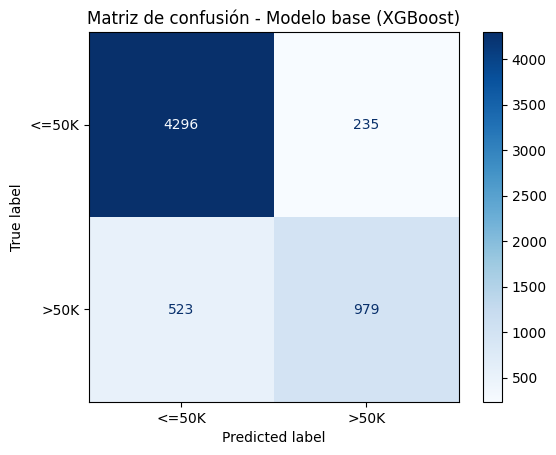

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

# Genera las predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

# Muestra la matriz de confusión del modelo
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["<=50K", ">50K"],  # Etiquetas de las clases
    cmap="Blues"                       # Paleta de colores
)

plt.title("Matriz de confusión - Modelo base (XGBoost)")
plt.show()

In [ ]:
joblib.dump(model, "model_adult.pkl")
joblib.dump((X_train, X_test, y_train, y_test), "data_split_adult.pkl")
joblib.dump(df, "df_adult_clean.pkl")

print("Modelo y datos guardados correctamente.")

Modelo y datos guardados correctamente.


## 7. Análisis global con SHAP

Igual que en la Sesión 2, calculamos los valores SHAP sobre el conjunto de entrenamiento y generamos el beeswarm plot. Esta vez, además de identificar las variables más influyentes en general, vamos a buscar específicamente dónde quedan ubicadas `sex`, `race` y `native.country`.

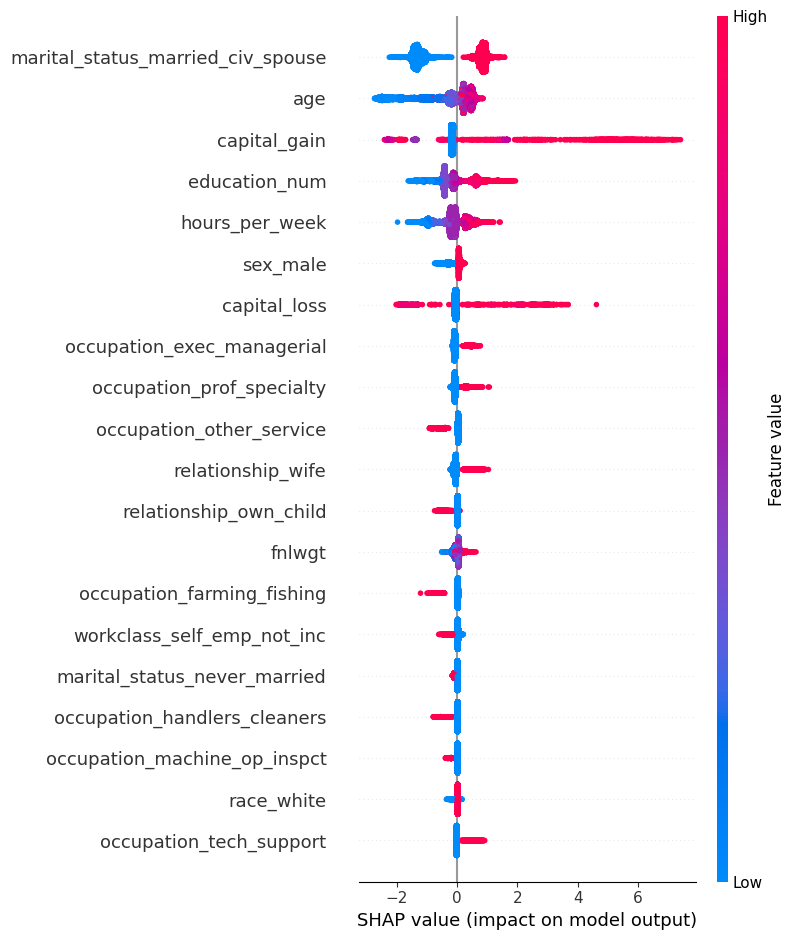

In [19]:
explainer = shap.TreeExplainer(model)
shap_values_train = explainer(X_train)

shap.summary_plot(shap_values_train, X_train, show=True)

### Reflexión crítica: ¿aparecen las variables sensibles entre las más influyentes?

Con nuestro modelo, el resultado fue el siguiente: `sex_male` quedó en el puesto **6 de 96** variables por importancia SHAP, por encima de variables como `capital_loss` o el tipo de ocupación. Es decir, el sexo de la persona es una de las variables más influyentes para que el modelo decida si predice un ingreso mayor a 50K.

Esto no significa que el modelo esté "programado" para discriminar; significa que **aprendió, de los datos históricos, que el sexo está fuertemente asociado al nivel de ingreso**, y lo está usando activamente para decidir.

`race_white` aparece más abajo en el ranking (puesto 19), y el resto de las categorías de raza y país de origen tienen una influencia individual menor. Esto ya es una pista importante: el sesgo no siempre es igual de fuerte en todas las variables sensibles, por lo que vale la pena revisar cada una por separado en lugar de asumir que "no hay sesgo" solo porque una de ellas no aparece en el top del gráfico.



**Preguntas que debemos hacernos como Data Scientist:**

- ¿Existe una diferencia real en los datos?
- ¿El conjunto de datos representa correctamente a toda la población?
- ¿Hay algún sesgo histórico en la información?

## 8. ¿El modelo reproduce desigualdades ya existentes en los datos?

El beeswarm nos dice qué tan importante es una variable para el modelo, pero no nos dice si el modelo está **generando** una desigualdad o simplemente **reflejando** una que ya existía en los datos históricos.

Para investigar esto, hacemos un chequeo simple y muy usado en auditorías de fairness: comparamos, para cada grupo (por sexo y por raza), la tasa **real** de personas con ingreso `>50K` contra la tasa que el modelo **predice** para ese mismo grupo. Si el modelo amplifica la brecha (la aumenta respecto a la realidad), es una señal de alerta adicional.

In [21]:
# Crea un DataFrame con las observaciones del test set, y agrega la predicción realizada por el modelo
resultados_test = df.loc[X_test.index].copy()
resultados_test["prediccion"] = y_pred

# Compara la proporción real y la proporción predicha de personas con ingresos superiores a 50K, agrupadas por sexo
print("Tasa real de ingreso >50K por sexo:")
print(resultados_test.groupby("sex")["income_bin"].mean().round(3))
print()

print("Tasa predicha de ingreso >50K por sexo:")
print(resultados_test.groupby("sex")["prediccion"].mean().round(3))

Tasa real de ingreso >50K por sexo:
sex
Female    0.115
Male      0.312
Name: income_bin, dtype: float64

Tasa predicha de ingreso >50K por sexo:
sex
Female    0.087
Male      0.255
Name: prediccion, dtype: float64


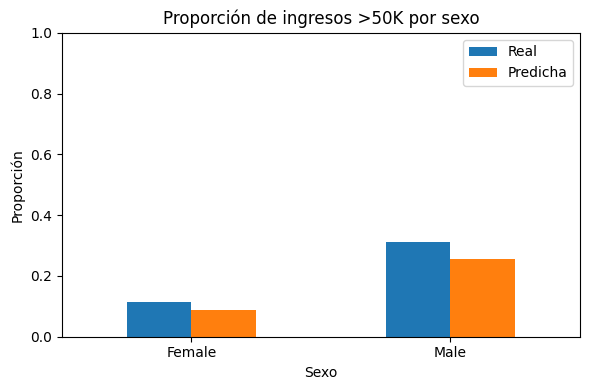

In [24]:
# Calcula las tasas reales y predichas por sexo
tasas = pd.DataFrame({
    "Real": resultados_test.groupby("sex")["income_bin"].mean(),
    "Predicha": resultados_test.groupby("sex")["prediccion"].mean()
})

# Grafica la comparación
ax = tasas.plot(
    kind="bar",
    figsize=(6, 4),
    rot=0
)

ax.set_title("Proporción de ingresos >50K por sexo")
ax.set_xlabel("Sexo")
ax.set_ylabel("Proporción")
ax.set_ylim(0, 1)
ax.legend(title="")

plt.tight_layout()
plt.show()

In [25]:
print("Tasa real de ingreso >50K por raza:")
print(resultados_test.groupby("race")["income_bin"].mean().round(3))
print()
print("Tasa predicha de ingreso >50K por raza:")
print(resultados_test.groupby("race")["prediccion"].mean().round(3))

Tasa real de ingreso >50K por raza:
race
Amer-Indian-Eskimo    0.159
Asian-Pac-Islander    0.246
Black                 0.147
Other                 0.059
White                 0.263
Name: income_bin, dtype: float64

Tasa predicha de ingreso >50K por raza:
race
Amer-Indian-Eskimo    0.114
Asian-Pac-Islander    0.218
Black                 0.115
Other                 0.020
White                 0.212
Name: prediccion, dtype: float64


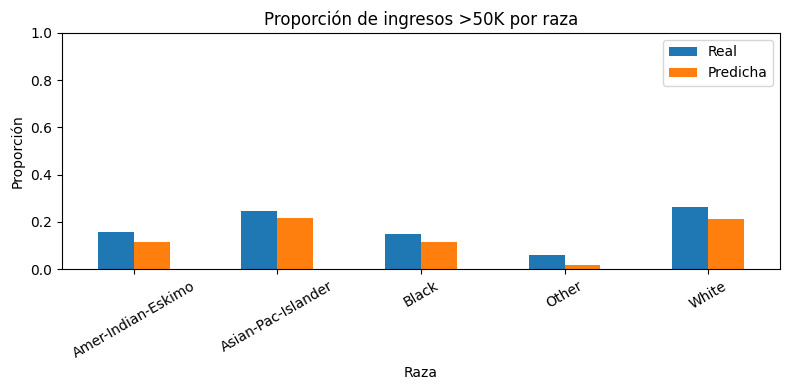

In [26]:
# Calcula las tasas reales y predichas por raza
tasas_raza = pd.DataFrame({
    "Real": resultados_test.groupby("race")["income_bin"].mean(),
    "Predicha": resultados_test.groupby("race")["prediccion"].mean()
})

# Grafica la comparación
ax = tasas_raza.plot(
    kind="bar",
    figsize=(8, 4),
    rot=30
)

ax.set_title("Proporción de ingresos >50K por raza")
ax.set_xlabel("Raza")
ax.set_ylabel("Proporción")
ax.set_ylim(0, 1)
ax.legend(title="")

plt.tight_layout()
plt.show()

En nuestros resultados: en los datos reales, un **31.2%** de los hombres tiene ingreso `>50K`, frente a solo un **11.5%** de las mujeres. El modelo predice tasas de **25.5%** para hombres y **8.7%** para mujeres. Es decir, el modelo no inventa esta brecha, pero tampoco la corrige: la reproduce casi en la misma proporción.

Esto es exactamente el tipo de hallazgo que vamos a documentar en la reflexión ética: el problema no nace necesariamente en el algoritmo, sino en que el algoritmo aprende fielmente los patrones históricos de los datos, incluyendo las desigualdades que esos datos contienen.

## 9. Análisis local: un caso donde el sexo influyó fuertemente

Para bajar esto a un caso concreto, buscamos un cliente del conjunto de prueba donde la variable `sex_male` haya tenido una contribución SHAP alta, y generamos su waterfall plot.

In [37]:
# Calcula los valores SHAP para todas las observaciones del conjunto de prueba
shap_values_test = explainer(X_test)

# Obtiene la posición de la variable "sex_male" dentro de las columnas
posicion_columna_sexo = list(X_test.columns).index("sex_male")

# Extrae la contribución SHAP de la variable "sex_male" para cada observación
contribucion_sexo = shap_values_test.values[:, posicion_columna_sexo]

# Entre las predicciones correctas, busca el caso donde la variable "sex_male" tuvo la mayor contribución positiva
correctas = pd.Series(contribucion_sexo, index=X_test.index)[y_pred == y_test.values] # extraemos solo las predicciones correctas
idx_caso_sexo = correctas.idxmax()

# Obtiene la posición de ese caso dentro de X_test
posicion_caso = X_test.index.get_loc(idx_caso_sexo)

# Muestra un gráfico Waterfall para explicar la predicción de ese caso
shap.plots.waterfall(shap_values_test[posicion_caso], show=True)

array([0, 0, 1, ..., 0, 1, 0])

**Reto: narrativa crítica para este caso**

Observa el waterfall: probablemente vas a notar que `sex_male` empuja la predicción claramente hacia `>50K`, incluso si otras variables terminan compensando ese efecto y el resultado final es `<=50K`. Esto ilustra algo importante: el sexo influye en la decisión del modelo **independientemente del resultado final**, no solo en los casos donde termina siendo la variable decisiva.

## Cierre del laboratorio

Con esto cerramos las 3 sesiones del Laboratorio de IA Ética: Sesgos y Explicabilidad. En resumen, recorrimos:

1. **Sesión 1:** entrenamos un modelo XGBoost y lo evaluamos con métricas estándar.
2. **Sesión 2:** usamos SHAP y LIME para explicar sus decisiones, a nivel global y en casos individuales.
3. **Sesión 3:** usamos esas mismas herramientas para auditar si el modelo se apoya en variables sensibles, y comparamos sus predicciones con los patrones reales de los datos.

Estas son exactamente las habilidades que vas a necesitar para el ejercicio final del módulo, donde vas a repetir este proceso completo de forma independiente sobre un nuevo caso.